# Experiment: Stage 2 Feature Review Analysis

This notebook visualizes the current **Stage 2 feature data** for the KOA-TriFQ pipeline using the active research workspace:

- JSN features from `features/jsn_v9_measurement_fix/jsn`
- Sclerosis features from `features/jsn_v9_measurement_fix/sclerosis`
- Osteophyte reviewed labels from `annotations/packages/feature_grading/feature_review_template.csv`

The goal is to support **research interpretation**, not only model debugging:
- how each feature family behaves across KL grades
- whether compartment-level patterns look clinically plausible
- where the three feature groups correlate or diverge


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path('/Users/naim/Desktop/patella-v4')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, kruskal

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


In [2]:
FEATURE_ROOT = REPO_ROOT / 'features' / 'jsn_v9_measurement_fix'
ANNOTATION_CSV = REPO_ROOT / 'annotations' / 'packages' / 'feature_grading' / 'feature_review_template.csv'
DATA_ROOT = REPO_ROOT / 'KneeXrayData' / 'ClsKLData' / 'kneeKL224'
JSN_MASK_ROOT = FEATURE_ROOT / 'jsn' / 'masks'

JSN_FEATURE_NAMES = [
    'mJSW_medial',
    'mJSW_lateral',
    *[f'jsw_profile_{i:02d}' for i in range(16)],
    'jsn_rate_medial',
    'jsn_rate_lateral',
    'jsw_ratio',
    'jsw_asymmetry',
]

SCL_FEATURE_NAMES = [
    'scl_grade_medial',
    'scl_grade_lateral',
    'scl_intensity_medial',
    'scl_intensity_lateral',
    'scl_fractal_dim_med',
    'scl_fractal_dim_lat',
    'scl_glcm_contrast_med',
    'scl_glcm_dissimilarity_med',
    'scl_glcm_homogeneity_med',
    'scl_glcm_energy_med',
    'scl_glcm_correlation_med',
    'scl_glcm_contrast_lat',
    'scl_glcm_dissimilarity_lat',
    'scl_glcm_homogeneity_lat',
    'scl_glcm_energy_lat',
    'scl_glcm_correlation_lat',
    'scl_lbp_entropy_med',
    'scl_lbp_entropy_lat',
]

OSP_GRADE_COLS = ['final_osp_mf', 'final_osp_lf', 'final_osp_mt', 'final_osp_lt']
SCL_GRADE_COLS = ['final_scl_medial', 'final_scl_lateral']


In [3]:
def load_feature_npz(npz_path: Path, feature_names: list[str], split: str) -> pd.DataFrame:
    data = np.load(npz_path, allow_pickle=True)
    rows = []
    for image_id in data.files:
        vector = np.asarray(data[image_id], dtype=np.float64)
        row = {'image_id': image_id, 'split': split}
        row.update({name: float(vector[i]) for i, name in enumerate(feature_names)})
        rows.append(row)
    return pd.DataFrame(rows)


def load_all_splits(subdir: str, feature_names: list[str], suffix: str) -> pd.DataFrame:
    frames = []
    for split in ['train', 'val', 'test']:
        path = FEATURE_ROOT / subdir / f'{split}_{suffix}.npz'
        if path.exists():
            frames.append(load_feature_npz(path, feature_names, split))
    return pd.concat(frames, ignore_index=True)


def summarize_series(series: pd.Series) -> pd.Series:
    return pd.Series({
        'count': int(series.notna().sum()),
        'mean': float(series.mean()),
        'std': float(series.std()),
        'min': float(series.min()),
        'median': float(series.median()),
        'max': float(series.max()),
    })


def add_osteophyte_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['osp_sum'] = out[OSP_GRADE_COLS].sum(axis=1)
    out['osp_max'] = out[OSP_GRADE_COLS].max(axis=1)
    out['osp_medial_sum'] = out[['final_osp_mf', 'final_osp_mt']].sum(axis=1)
    out['osp_lateral_sum'] = out[['final_osp_lf', 'final_osp_lt']].sum(axis=1)
    out['osp_femoral_sum'] = out[['final_osp_mf', 'final_osp_lf']].sum(axis=1)
    out['osp_tibial_sum'] = out[['final_osp_mt', 'final_osp_lt']].sum(axis=1)
    return out


def overlay_mask(image_id: str, split: str, alpha: float = 0.35):
    img_path = DATA_ROOT / split / str(int(metadata_df.set_index('image_id').loc[image_id, 'kl_grade'])) / f'{image_id}.png'
    mask_path = JSN_MASK_ROOT / f'{image_id}_mask.npy'
    image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    mask = np.load(mask_path) if mask_path.exists() else None
    if image is None:
        raise FileNotFoundError(img_path)
    canvas = np.stack([image, image, image], axis=-1)
    if mask is not None:
        canvas = canvas.astype(np.float32)
        medial = mask == 1
        lateral = mask == 2
        canvas[medial] = (1 - alpha) * canvas[medial] + alpha * np.array([0, 255, 0])
        canvas[lateral] = (1 - alpha) * canvas[lateral] + alpha * np.array([255, 80, 80])
        canvas = np.clip(canvas, 0, 255).astype(np.uint8)
    return canvas


In [4]:
metadata_df = pd.read_csv(ANNOTATION_CSV)
metadata_df = add_osteophyte_summary(metadata_df)

jsn_df = load_all_splits('jsn', JSN_FEATURE_NAMES, 'jsn_features')
scl_df = load_all_splits('sclerosis', SCL_FEATURE_NAMES, 'sclerosis_features')

analysis_df = (
    metadata_df
    .merge(jsn_df, on=['image_id', 'split'], how='left', validate='one_to_one')
    .merge(scl_df, on=['image_id', 'split'], how='left', validate='one_to_one')
)

print('metadata_df shape:', metadata_df.shape)
print('jsn_df shape:', jsn_df.shape)
print('scl_df shape:', scl_df.shape)
print('analysis_df shape:', analysis_df.shape)
analysis_df[['image_id', 'split', 'kl_grade', 'osp_sum', 'mJSW_medial', 'mJSW_lateral', 'scl_grade_medial', 'scl_grade_lateral']].head()


metadata_df shape: (500, 30)
jsn_df shape: (8260, 24)
scl_df shape: (8260, 20)
analysis_df shape: (500, 70)


,image_id,split,kl_grade,osp_sum,mJSW_medial,mJSW_lateral,scl_grade_medial,scl_grade_lateral
0,9001695L,train,0,0.0,10.978881,13.368289,0.0,0.0
1,9001897L,train,0,2.0,9.300457,17.047654,1.0,0.0
2,9003126L,train,0,0.0,13.052141,14.946442,0.0,0.0
3,9003126R,train,0,4.0,12.071416,16.000000,0.0,0.0
4,9003430L,train,0,0.0,12.596810,16.866008,0.0,0.0


## 1. Coverage and Data Sanity

This section verifies that the merged Stage 2 table has all expected components:
- manual osteophyte labels
- manual sclerosis labels
- extracted JSN features
- extracted sclerosis feature vectors


In [5]:
coverage = pd.DataFrame({
    'rows': [len(analysis_df)],
    'jsn_missing_rows': [int(analysis_df[['mJSW_medial', 'mJSW_lateral']].isna().any(axis=1).sum())],
    'sclerosis_missing_rows': [int(analysis_df[['scl_grade_medial', 'scl_grade_lateral']].isna().any(axis=1).sum())],
    'osteophyte_missing_rows': [int(analysis_df[OSP_GRADE_COLS].isna().any(axis=1).sum())],
})
coverage


,rows,jsn_missing_rows,sclerosis_missing_rows,osteophyte_missing_rows
0,500,0,0,0


## 1A. Compact Statistics

These summaries make the notebook useful for actual reporting:
- descriptive means by KL grade
- monotonic association with KL grade using Spearman correlation
- global group difference using Kruskal-Wallis across KL 0–4


In [6]:
stat_features = [
    'mJSW_medial', 'mJSW_lateral', 'jsn_rate_medial', 'jsn_rate_lateral',
    'osp_sum', 'osp_medial_sum', 'osp_lateral_sum',
    'final_scl_medial', 'final_scl_lateral',
    'scl_intensity_medial', 'scl_intensity_lateral',
]

summary_by_kl = analysis_df.groupby('kl_grade')[stat_features].mean().round(3)
summary_by_kl


def feature_stats(df: pd.DataFrame, feature: str) -> dict:
    rho, p_s = spearmanr(df['kl_grade'], df[feature], nan_policy='omit')
    groups = [group[feature].dropna().to_numpy() for _, group in df.groupby('kl_grade')]
    h_stat, p_kw = kruskal(*groups)
    return {
        'feature': feature,
        'spearman_rho_vs_kl': float(rho),
        'spearman_p': float(p_s),
        'kruskal_h': float(h_stat),
        'kruskal_p': float(p_kw),
    }

stats_df = pd.DataFrame([feature_stats(analysis_df, feature) for feature in stat_features])
stats_df.sort_values('spearman_rho_vs_kl', key=lambda s: s.abs(), ascending=False)


,feature,spearman_rho_vs_kl,spearman_p,kruskal_h,kruskal_p
4,osp_sum,0.841138,4.881186e-135,381.609925,2.614072e-81
5,osp_medial_sum,0.782977,9.637505e-105,326.413754,2.165436e-69
6,osp_lateral_sum,0.705615,1.592432e-76,277.697942,6.987429e-59
7,final_scl_medial,0.628741,2.259740e-56,273.538797,5.507540e-58
2,jsn_rate_medial,0.592670,9.652440e-49,199.665372,4.434214e-42
0,mJSW_medial,-0.585262,2.722457e-47,194.266516,6.417684e-41
8,final_scl_lateral,0.575595,1.871879e-45,254.224453,8.006674e-54
3,jsn_rate_lateral,0.531248,9.265746e-38,152.854314,4.977380e-32
1,mJSW_lateral,-0.524179,1.232673e-36,150.256707,1.793565e-31
9,scl_intensity_medial,0.134644,2.553398e-03,12.936475,1.159039e-02


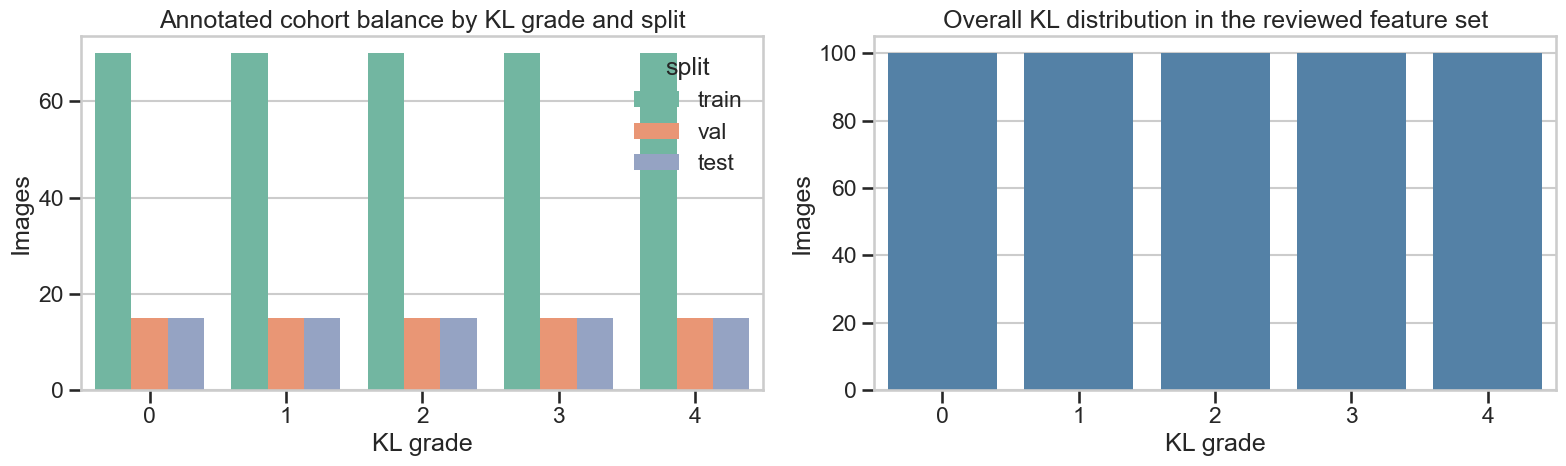

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=analysis_df, x='kl_grade', hue='split', ax=axes[0])
axes[0].set_title('Annotated cohort balance by KL grade and split')
axes[0].set_xlabel('KL grade')
axes[0].set_ylabel('Images')

sns.countplot(data=analysis_df.assign(side='both'), x='kl_grade', ax=axes[1], color='steelblue')
axes[1].set_title('Overall KL distribution in the reviewed feature set')
axes[1].set_xlabel('KL grade')
axes[1].set_ylabel('Images')

plt.tight_layout()


## 2. JSN Feature Behavior Across KL Grades

The most interpretable JSN quantities are the compartment-wise minimum joint-space widths and derived narrowing rates.


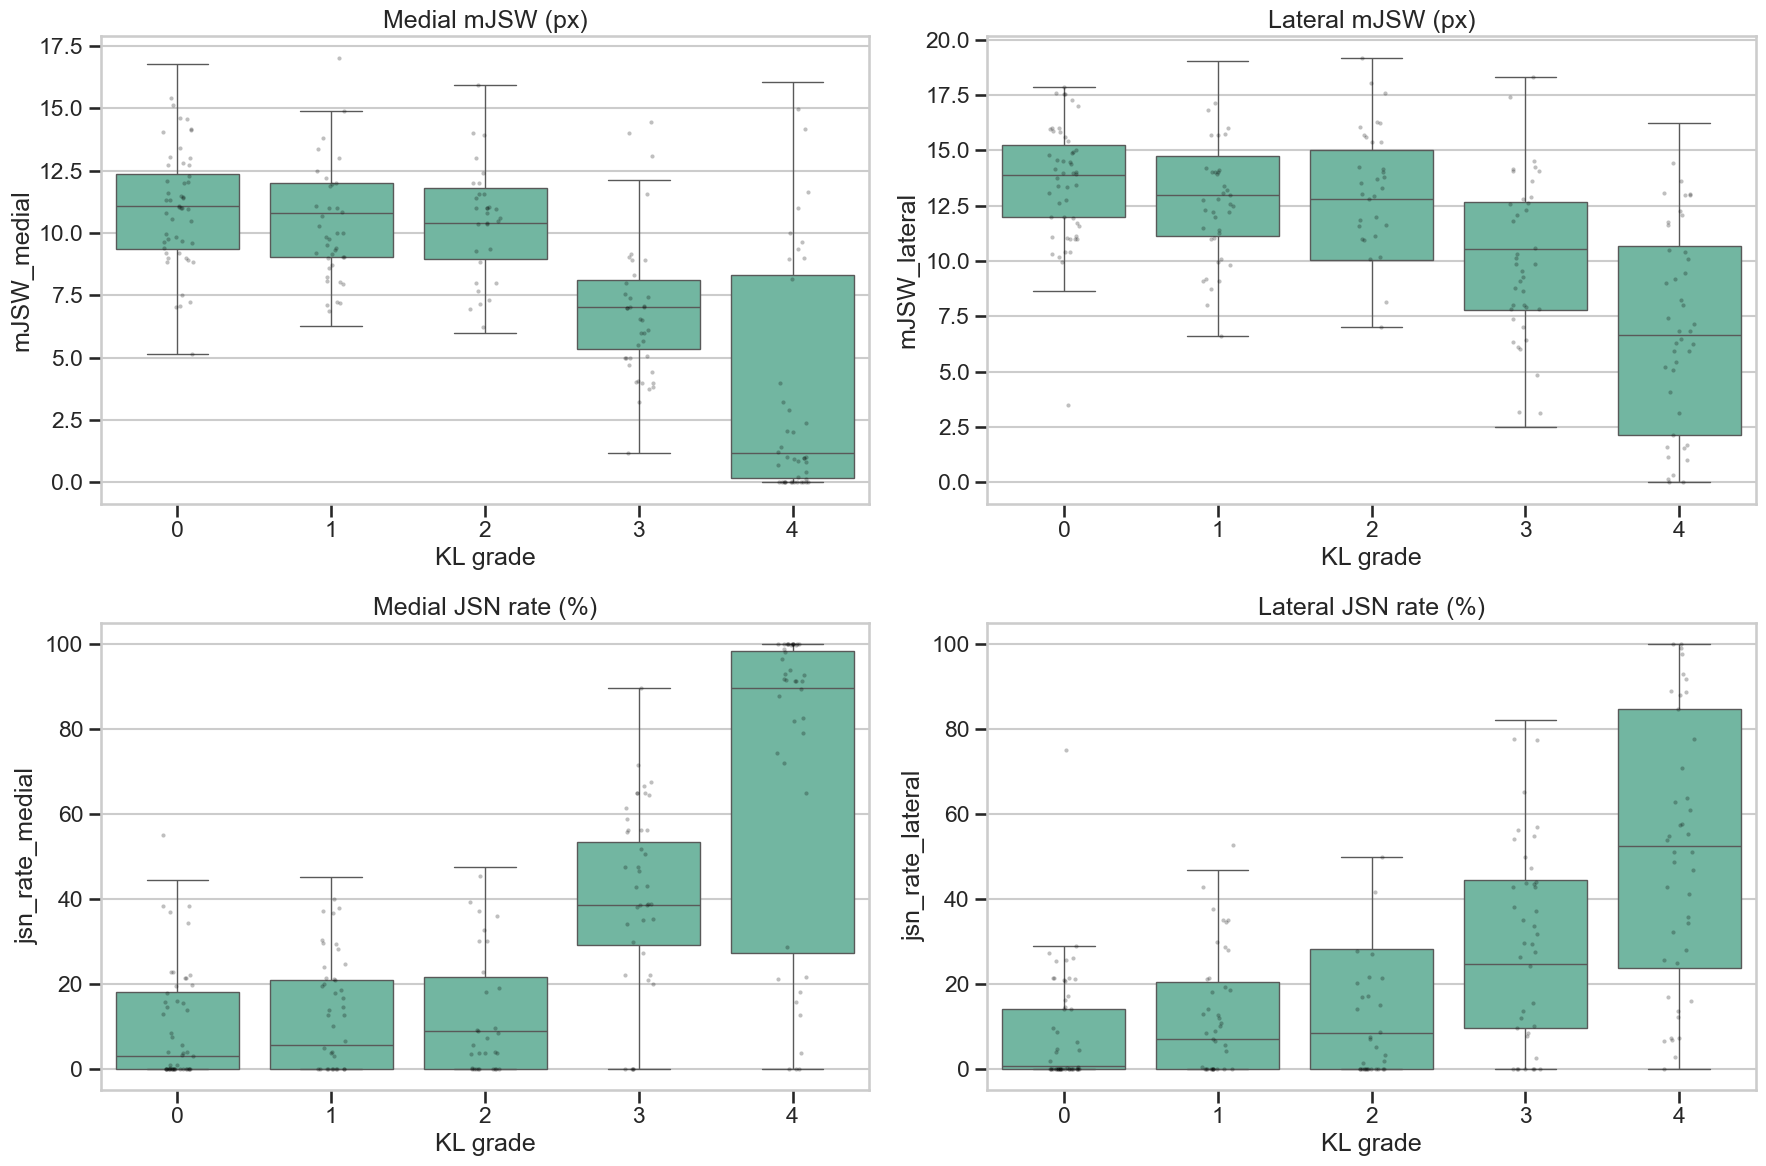

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
jsn_plot_cols = [
    ('mJSW_medial', 'Medial mJSW (px)'),
    ('mJSW_lateral', 'Lateral mJSW (px)'),
    ('jsn_rate_medial', 'Medial JSN rate (%)'),
    ('jsn_rate_lateral', 'Lateral JSN rate (%)'),
]
for ax, (col, title) in zip(axes.flatten(), jsn_plot_cols):
    sns.boxplot(data=analysis_df, x='kl_grade', y=col, ax=ax, showfliers=False)
    sns.stripplot(data=analysis_df.sample(min(len(analysis_df), 200), random_state=42), x='kl_grade', y=col, ax=ax, color='black', alpha=0.25, size=3)
    ax.set_title(title)
    ax.set_xlabel('KL grade')
plt.tight_layout()


In [9]:
jsn_summary = analysis_df.groupby('kl_grade')[['mJSW_medial', 'mJSW_lateral', 'jsn_rate_medial', 'jsn_rate_lateral', 'jsw_asymmetry']].mean().round(3)
jsn_summary


,mJSW_medial,mJSW_lateral,jsn_rate_medial,jsn_rate_lateral,jsw_asymmetry
kl_grade,,,,,
0,11.002,13.647,9.908,8.267,2.735
1,10.840,12.942,10.969,11.747,2.772
2,10.320,12.635,13.617,14.777,3.309
3,7.147,10.299,38.682,28.679,5.142
4,3.787,6.676,68.737,52.552,8.252


## 3. Osteophyte Burden and Site Patterns

There is not yet a dedicated osteophyte feature export in `features/`, so this section uses the reviewed per-site osteophyte labels and derives summary burden features directly.


,MF,LF,MT,LT
kl_grade,,,,
0,0.08,0.12,0.11,0.11
1,0.23,0.33,0.84,0.73
2,0.33,0.28,0.65,0.53
3,0.69,0.68,0.94,0.89
4,0.92,0.89,1.00,0.97


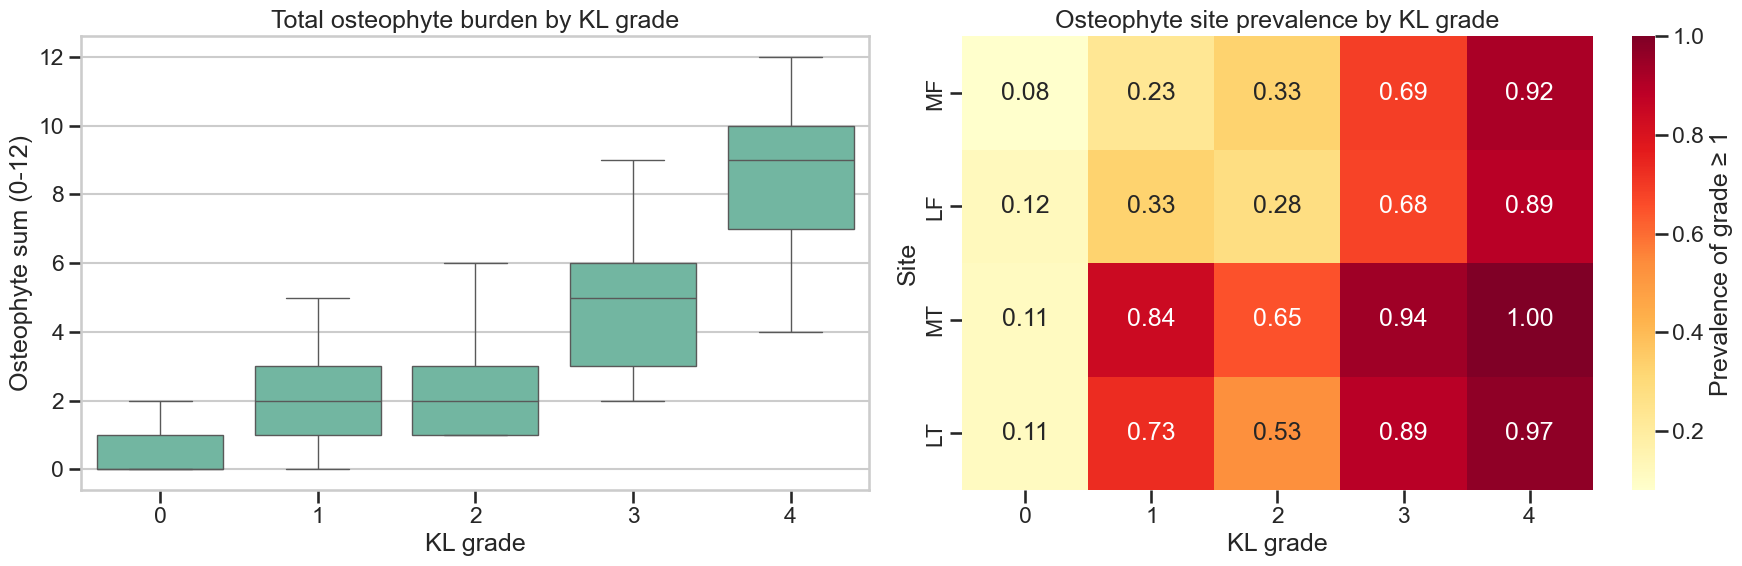

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=analysis_df, x='kl_grade', y='osp_sum', ax=axes[0], showfliers=False)
axes[0].set_title('Total osteophyte burden by KL grade')
axes[0].set_xlabel('KL grade')
axes[0].set_ylabel('Osteophyte sum (0-12)')

site_prevalence = analysis_df.groupby('kl_grade')[OSP_GRADE_COLS].apply(lambda x: (x >= 1).mean()).rename(columns={
    'final_osp_mf': 'MF',
    'final_osp_lf': 'LF',
    'final_osp_mt': 'MT',
    'final_osp_lt': 'LT',
})
sns.heatmap(site_prevalence.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Prevalence of grade ≥ 1'})
axes[1].set_title('Osteophyte site prevalence by KL grade')
axes[1].set_xlabel('KL grade')
axes[1].set_ylabel('Site')

plt.tight_layout()
site_prevalence


## 4. Sclerosis Grades and Texture-Driven Features

This section combines the manual compartment grades with the extracted sclerosis feature vectors.


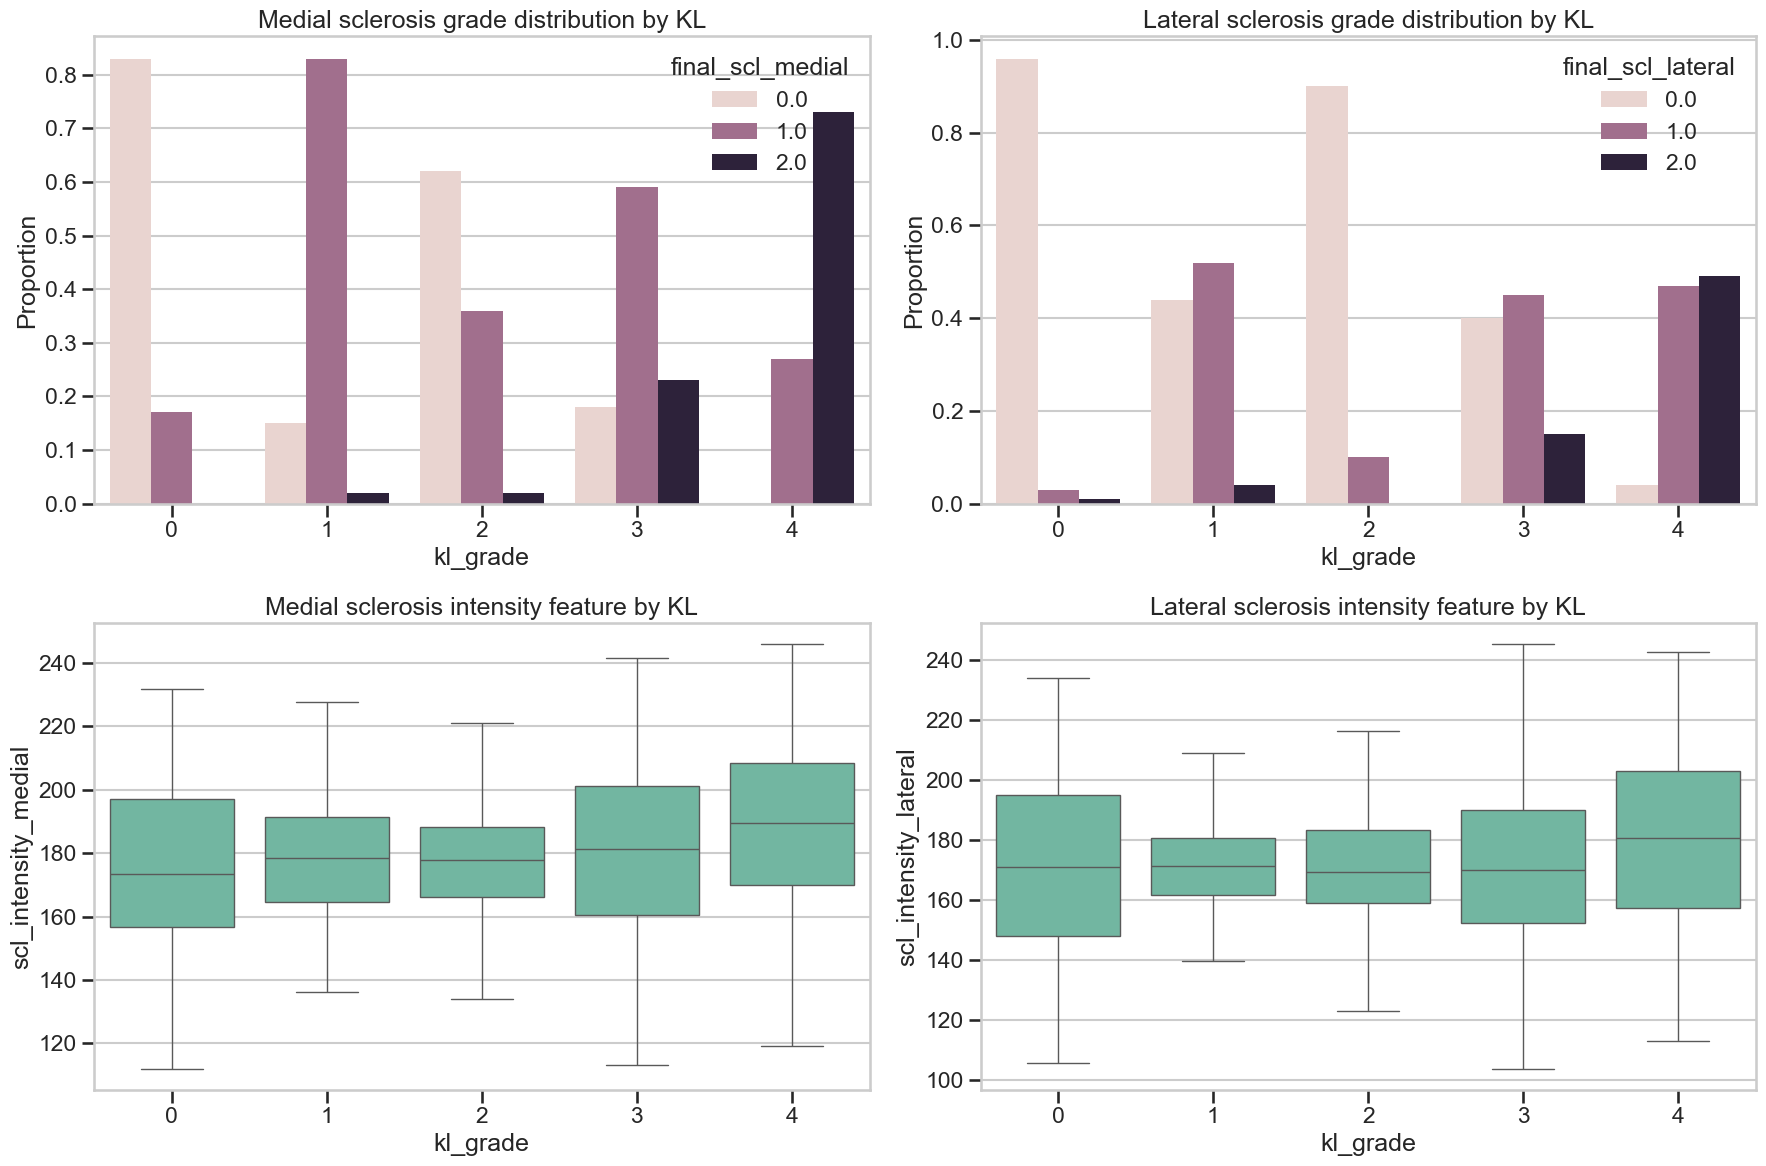

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

med_dist = (analysis_df.groupby('kl_grade')['final_scl_medial'].value_counts(normalize=True).rename('ratio').reset_index())
lat_dist = (analysis_df.groupby('kl_grade')['final_scl_lateral'].value_counts(normalize=True).rename('ratio').reset_index())

sns.barplot(data=med_dist, x='kl_grade', y='ratio', hue='final_scl_medial', ax=axes[0,0])
axes[0,0].set_title('Medial sclerosis grade distribution by KL')
axes[0,0].set_ylabel('Proportion')

sns.barplot(data=lat_dist, x='kl_grade', y='ratio', hue='final_scl_lateral', ax=axes[0,1])
axes[0,1].set_title('Lateral sclerosis grade distribution by KL')
axes[0,1].set_ylabel('Proportion')

sns.boxplot(data=analysis_df, x='kl_grade', y='scl_intensity_medial', ax=axes[1,0], showfliers=False)
axes[1,0].set_title('Medial sclerosis intensity feature by KL')

sns.boxplot(data=analysis_df, x='kl_grade', y='scl_intensity_lateral', ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Lateral sclerosis intensity feature by KL')

plt.tight_layout()


In [12]:
texture_summary = analysis_df.groupby('kl_grade')[['scl_grade_medial', 'scl_grade_lateral', 'scl_intensity_medial', 'scl_intensity_lateral', 'scl_lbp_entropy_med', 'scl_lbp_entropy_lat']].mean().round(3)
texture_summary


,scl_grade_medial,scl_grade_lateral,scl_intensity_medial,scl_intensity_lateral,scl_lbp_entropy_med,scl_lbp_entropy_lat
kl_grade,,,,,,
0,0.17,0.05,175.988,171.391,9.863,9.819
1,0.87,0.60,179.005,173.497,9.960,9.909
2,0.40,0.10,176.230,170.103,10.038,9.956
3,1.05,0.75,178.730,170.296,10.145,9.906
4,1.73,1.45,187.084,178.407,10.035,9.852


## 5. Cross-Feature Relationships

This view helps answer whether the three feature families move together as expected.


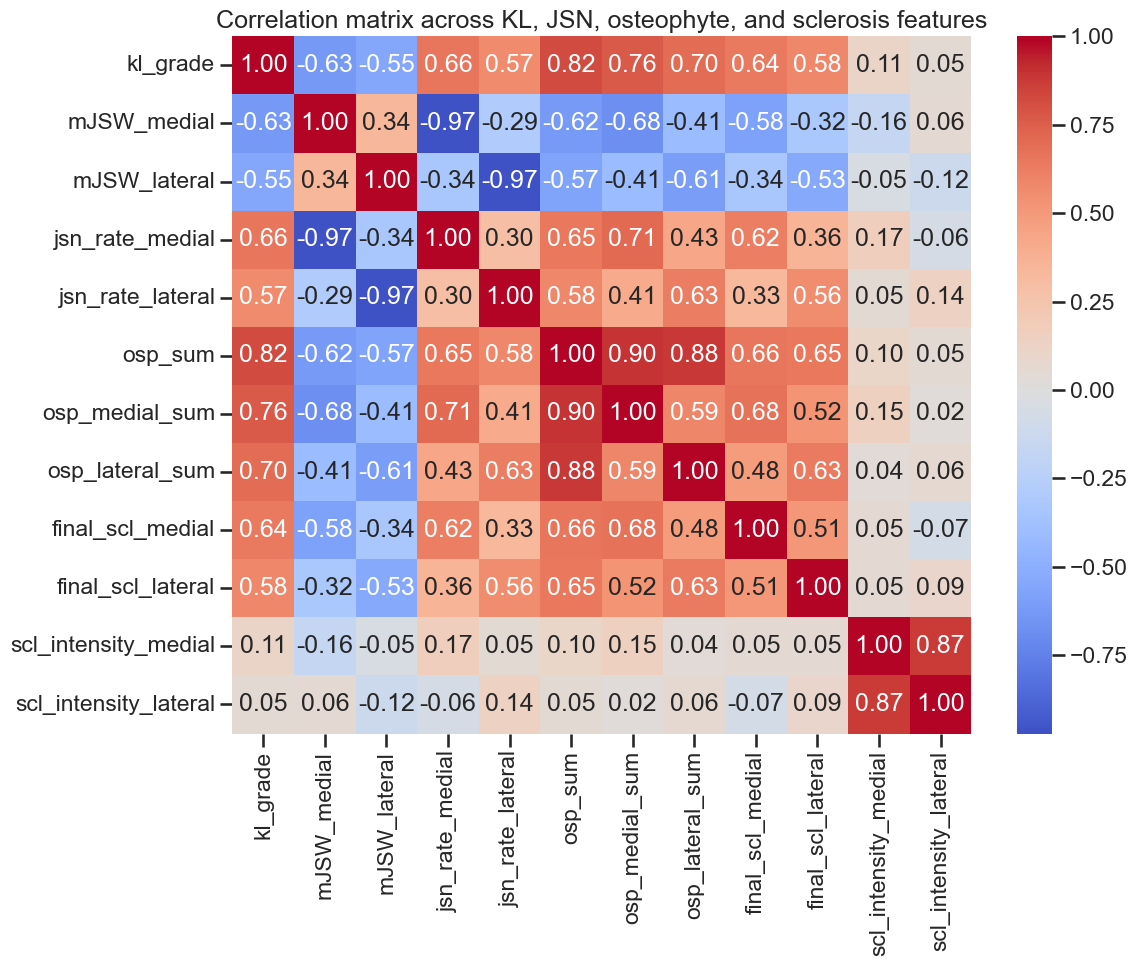

In [13]:
selected_cols = [
    'kl_grade',
    'mJSW_medial', 'mJSW_lateral', 'jsn_rate_medial', 'jsn_rate_lateral',
    'osp_sum', 'osp_medial_sum', 'osp_lateral_sum',
    'final_scl_medial', 'final_scl_lateral',
    'scl_intensity_medial', 'scl_intensity_lateral',
]

corr = analysis_df[selected_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlation matrix across KL, JSN, osteophyte, and sclerosis features')
plt.tight_layout()


,image_id,kl_grade,split,pc1,pc2
0,9001695L,0,train,-3.197696,-0.734766
1,9001897L,0,train,-1.332239,0.982769
2,9003126L,0,train,-3.337232,2.618939
3,9003126R,0,train,-1.283192,1.684229
4,9003430L,0,train,-3.446973,-0.906627


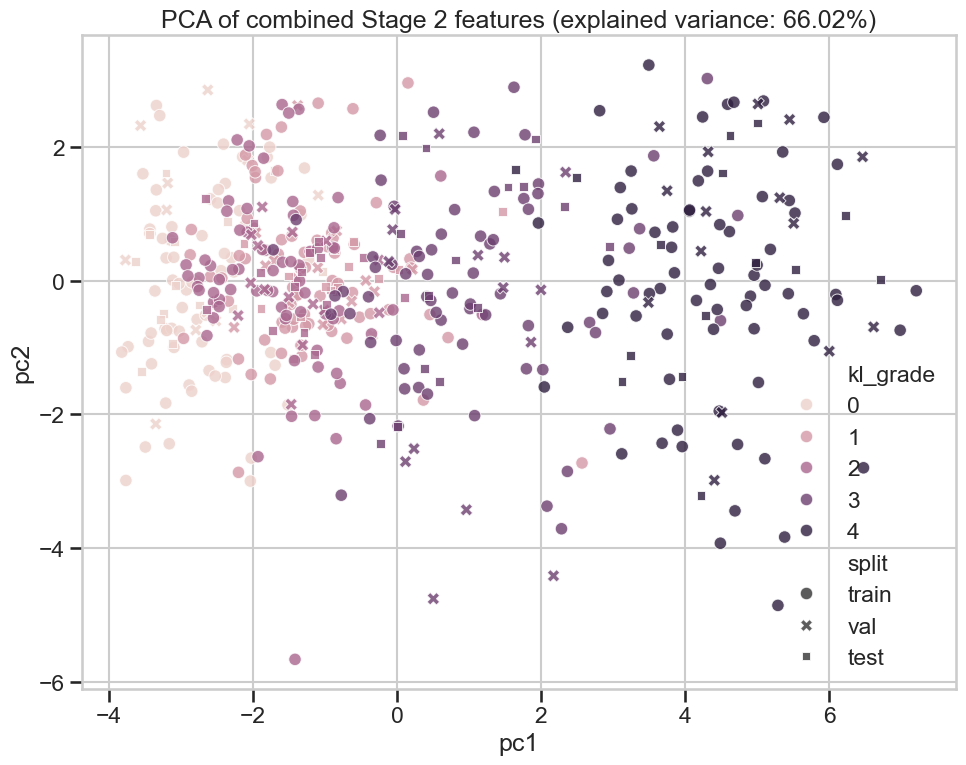

In [14]:
combined_cols = [
    'mJSW_medial', 'mJSW_lateral', 'jsn_rate_medial', 'jsn_rate_lateral', 'jsw_asymmetry',
    'osp_sum', 'osp_medial_sum', 'osp_lateral_sum', 'osp_femoral_sum', 'osp_tibial_sum',
    'final_scl_medial', 'final_scl_lateral', 'scl_intensity_medial', 'scl_intensity_lateral',
]

pca_input = analysis_df[combined_cols].dropna().copy()
scaler = StandardScaler()
X = scaler.fit_transform(pca_input)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
plot_df = analysis_df.loc[pca_input.index, ['image_id', 'kl_grade', 'split']].copy()
plot_df['pc1'] = coords[:, 0]
plot_df['pc2'] = coords[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x='pc1', y='pc2', hue='kl_grade', style='split', alpha=0.8)
plt.title(f'PCA of combined Stage 2 features (explained variance: {pca.explained_variance_ratio_.sum():.2%})')
plt.tight_layout()
plot_df.head()


## 6. Case Viewer

Use this helper to inspect one reviewed image together with:
- the source X-ray
- the current JSN mask overlay
- the key JSN, osteophyte, and sclerosis values


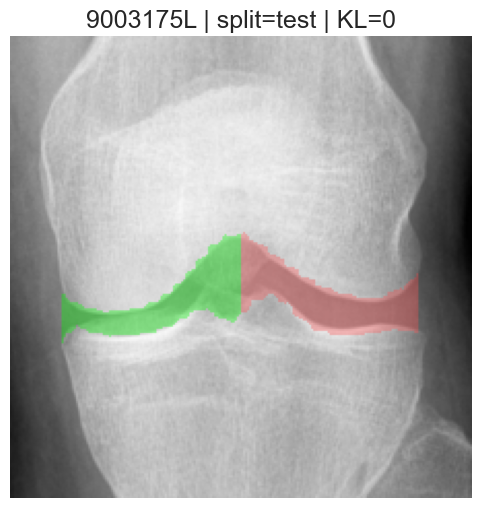

mJSW_medial                9.241436
mJSW_lateral              14.625322
jsn_rate_medial           19.201952
jsn_rate_lateral                0.0
final_osp_mf                    0.0
final_osp_lf                    0.0
final_osp_mt                    0.0
final_osp_lt                    0.0
osp_sum                         0.0
final_scl_medial                1.0
final_scl_lateral               0.0
scl_intensity_medial     210.154785
scl_intensity_lateral    191.066895
confidence_mf                  high
confidence_lf                  high
confidence_mt                  high
confidence_lt                  high
scl_confidence_med           medium
scl_confidence_lat             high
Name: 9003175L, dtype: object

In [15]:
def show_case(image_id: str):
    row = analysis_df.set_index('image_id').loc[image_id]
    overlay = overlay_mask(image_id, row['split'])

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(overlay)
    ax.set_title(f"{image_id} | split={row['split']} | KL={int(row['kl_grade'])}")
    ax.axis('off')
    plt.show()

    display_cols = [
        'mJSW_medial', 'mJSW_lateral', 'jsn_rate_medial', 'jsn_rate_lateral',
        'final_osp_mf', 'final_osp_lf', 'final_osp_mt', 'final_osp_lt', 'osp_sum',
        'final_scl_medial', 'final_scl_lateral', 'scl_intensity_medial', 'scl_intensity_lateral',
        'confidence_mf', 'confidence_lf', 'confidence_mt', 'confidence_lt',
        'scl_confidence_med', 'scl_confidence_lat',
    ]
    return row[display_cols]

show_case('9003175L')


## 7. Suggested Analysis Questions

- Do medial and lateral JSN features separate KL grades monotonically?
- Is osteophyte burden increasing with KL grade in a clinically plausible way?
- Are sclerosis grades and texture features aligned, or is there evidence of calibration drift?
- Which cases look unusual when the three feature families disagree strongly?
- If osteophyte model outputs are added later, this notebook can be extended by swapping in `features/.../osteophyte/*.npz` for the current label-derived summaries.
